In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb

In [2]:
df = pd.read_csv("feature_engineered_dataset.csv")

In [5]:
#Define Target Variable Pricing decisions depend on demand -> so we predict demand
#Demand = number of units sold
y = df["units_sold"]

In [11]:
#Define features
X = df.drop(["units_sold", "date", "store_id", "product_id"], axis=1)

X = pd.get_dummies(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

#n_estimators=100 → number of trees
#learning_rate=0.1 → controls learning speed
#max_depth=6 → controls complexity

In [14]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
y_pred_xgb = xgb_model.predict(X_test)

In [16]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)
#Lower rmse -> better model

XGBoost RMSE: 0.8802464757175419


In [17]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

In [18]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4321
[LightGBM] [Info] Number of data points in the train set: 58480, number of used features: 39
[LightGBM] [Info] Start training from score 136.747623
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
y_pred_lgb = lgb_model.predict(X_test)

In [20]:
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
print("LightGBM RMSE:", rmse_lgb)

LightGBM RMSE: 1.0098764365467208


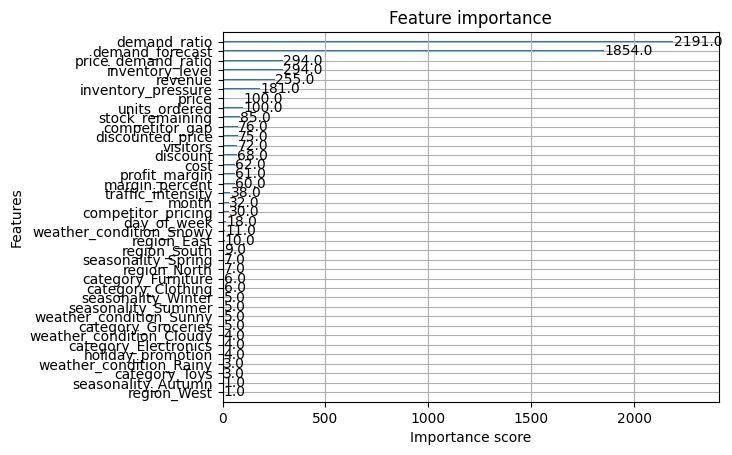

In [21]:
xgb.plot_importance(xgb_model)
import matplotlib.pyplot as plt
plt.show()

In [22]:
df["predicted_demand"] = xgb_model.predict(X)

In [23]:
def optimize_price(row):
    if row["predicted_demand"] > row["units_sold"]:
        return row["price"] * 1.05
    else:
        return row["price"] * 0.95

df["ml_price"] = df.apply(optimize_price, axis=1)


#If demand predicted higher → increase price Else → decrease price

In [24]:
df["ml_revenue"] = df["ml_price"] * df["units_sold"]

In [26]:
df["baseline_revenue"] = df["price"] * df["units_sold"]

In [27]:
lift = (df["ml_revenue"].sum() - df["baseline_revenue"].sum()) / df["baseline_revenue"].sum() * 100
print("ML Revenue Lift (%):", lift)

ML Revenue Lift (%): -0.028327385525272156


In [ ]:
#The ML model predicted demand successfully, but the pricing strategy resulted in a slight decrease in revenue (-0.028%). 
#This indicates that the current model and pricing logic need improvement to outperform the baseline.